# **2. Cloverleaf Bridge**
### **2.1. Dataset and Preprocessing**
**2.1.1. Image Loading and Exploration**

I used OpenCV to load the image and displayed it using Matplotlib after converting it to RGB format. I extracted basic information like dimensions, data type, and pixel value range. To analyze pixel intensity distribution, I implemented a custom histogram and compared it with OpenCV’s `calcHist(),` plotting both to verify accuracy and understand the image's properties.

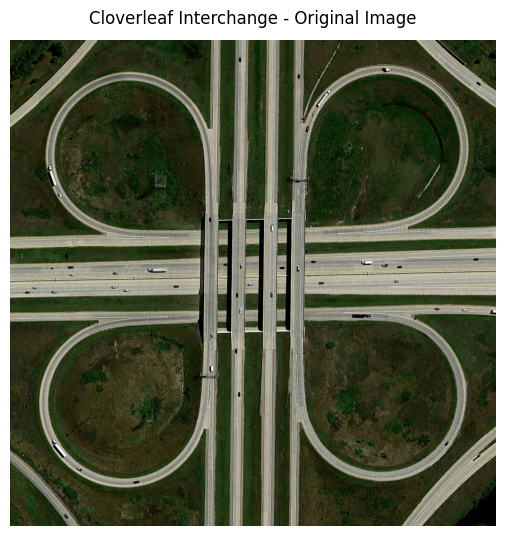



Image Information:
  Dimensions        : 1207 x 1207 pixels  (3 channels)
  Pixel value range : 0 - 253
  Data type         : uint8
  Grayscale mean    : 73.30  std: 54.62



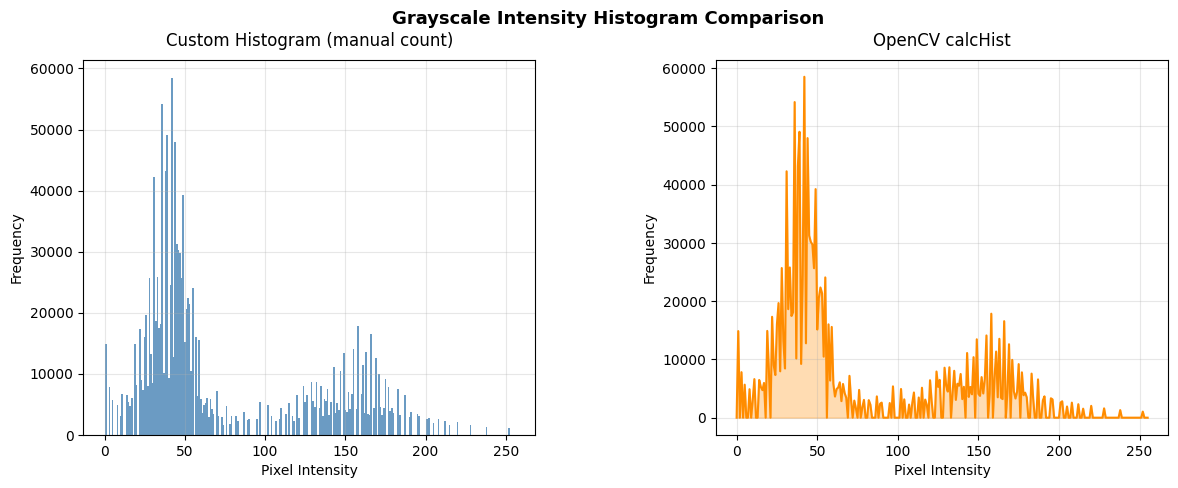

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def load_cloverleaf_image(path="cloverleaf_interchange.png"):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray      = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # show original image
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Cloverleaf Interchange - Original Image", pad=12)
    plt.axis("off")
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n")

    # basic image statistics
    h, w, c = image.shape
    print("Image Information:")
    print(f"  Dimensions        : {w} x {h} pixels  ({c} channels)")
    print(f"  Pixel value range : {image.min()} - {image.max()}")
    print(f"  Data type         : {image.dtype}")
    print(f"  Grayscale mean    : {gray.mean():.2f}  std: {gray.std():.2f}")
    print()

    # custom histogram vs OpenCV histogram, shown side by side
    hist_custom = np.zeros(256, dtype=int)
    for val in gray.ravel():
        hist_custom[val] += 1

    hist_cv = cv2.calcHist([gray], [0], None, [256], [0, 256])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.subplots_adjust(wspace=0.4, top=0.88, bottom=0.13)

    axes[0].bar(range(256), hist_custom, color="steelblue", width=1.0, alpha=0.8)
    axes[0].set_title("Custom Histogram (manual count)", fontsize=12, pad=10)
    axes[0].set_xlabel("Pixel Intensity")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist_cv, color="darkorange", linewidth=1.5)
    axes[1].fill_between(range(256), hist_cv.flatten(), alpha=0.3, color="darkorange")
    axes[1].set_title("OpenCV calcHist", fontsize=12, pad=10)
    axes[1].set_xlabel("Pixel Intensity")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Grayscale Intensity Histogram Comparison", fontsize=13,
                 fontweight="bold", y=0.98)
    plt.show()
    print("\n")
    return image


image = load_cloverleaf_image()


**2.1.2. Image Preprocessing**

The preprocess_image(image) function enhances the image using the following steps:

    1. Grayscale Conversion: Simplifies the image to intensity values using cv2.cvtColor.
    2. Contrast Enhancement (CLAHE): Improves local contrast for better visibility in low-contrast regions.
    3. Gaussian Blur: Reduces noise and smoothens the image to avoid false edges.
    4. Canny Edge Detection: Highlights prominent edges using intensity gradients.
    5. Morphological Closing: Unifies broken edges with an elliptical kernel to emphasize circular structures.

These techniques refine the image for effective detection of cloverleaf patterns.

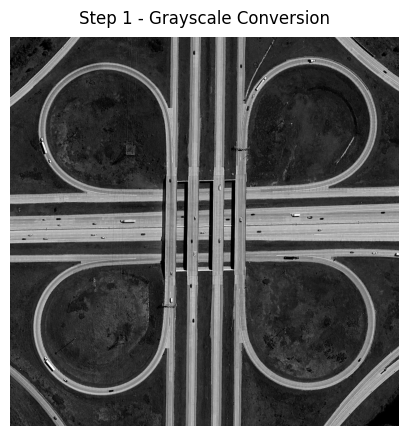

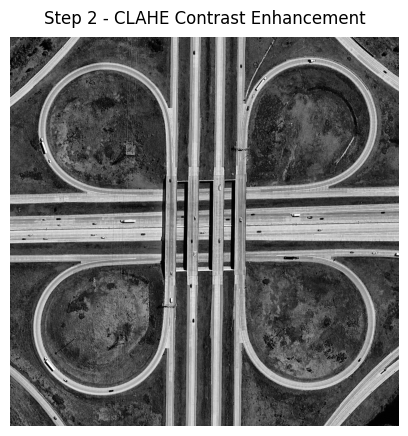

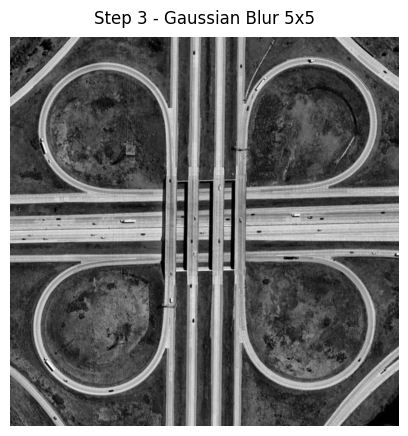

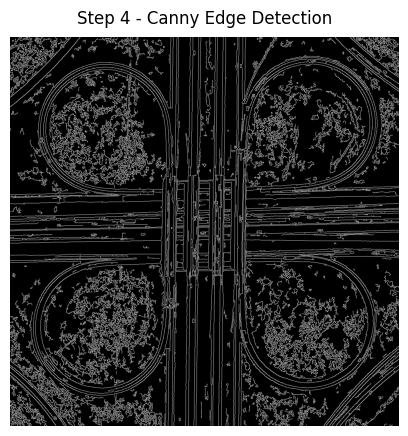

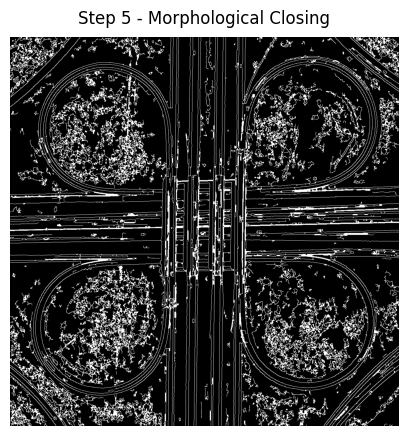

In [2]:
def show_step(img, title):
    plt.figure(figsize=(7, 5))
    cmap = None if img.ndim == 3 else "gray"
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img, cmap=cmap)
    plt.title(title, fontsize=12, pad=10)
    plt.axis("off")
    plt.tight_layout(pad=3.0)
    plt.show()
    print("\n")


def preprocess_image(image, display_steps=False):
    # step 1: grayscale — reduces 3 channels to 1 for Hough detection
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if display_steps:
        show_step(gray, "Step 1 - Grayscale Conversion")

    # step 2: CLAHE contrast enhancement — helps with uneven aerial lighting
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    if display_steps:
        show_step(enhanced, "Step 2 - CLAHE Contrast Enhancement")

    # step 3: gaussian blur — suppresses road texture noise before edge detection
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)
    if display_steps:
        show_step(blurred, "Step 3 - Gaussian Blur 5x5")

    # step 4: canny edge detection — highlights the circular arc boundaries
    edges = cv2.Canny(blurred, 50, 150)
    if display_steps:
        show_step(edges, "Step 4 - Canny Edge Detection")

    # step 5: morphological closing — fills small gaps in the three-quarter arcs
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    if display_steps:
        show_step(closed, "Step 5 - Morphological Closing")

    return closed


preprocessed = preprocess_image(image, display_steps=True)


### **2.2. Cloverleaf Detection and Measurement**
**2.2.1. Cloverleaf Detection and Visualization**

The detection of cloverleaf structures was achieved using the Hough Circle Transform on a preprocessed image. Preprocessing involved grayscale conversion, contrast enhancement with CLAHE, Gaussian blur for noise reduction, Canny edge detection for prominent edges, and morphological closing to unify broken arcs. The Hough Circle Transform was configured with parameters to detect circles within specified size ranges, ensuring minimal overlap and accurate detection of circular features.

Detected circles were visualized by overlaying their boundaries and centers on the original image, allowing for easy verification of results. Parameter tuning addressed challenges like false positives, distorted shapes, and varying circle sizes. This approach effectively highlights cloverleaf patterns while balancing accuracy and robustness.

Detected 4 cloverleaf loop(s)


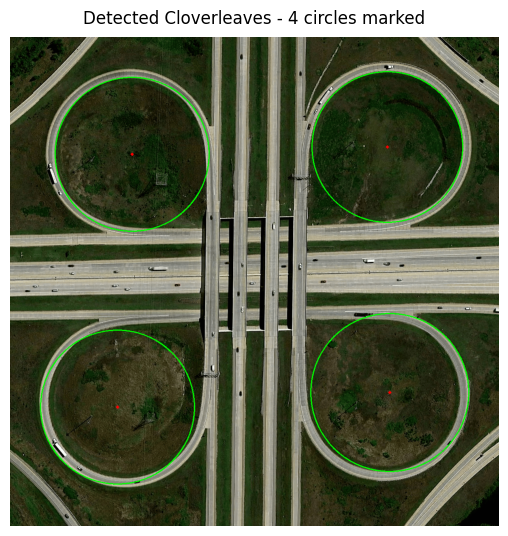

In [14]:
def detect_cloverleaves(preprocessed_image):
    # Hough circle transform — parameters tuned for cloverleaf loop radii
    circles = cv2.HoughCircles(
        preprocessed_image,
        cv2.HOUGH_GRADIENT,
        dp=1.2,          # inverse resolution ratio
        minDist=180,     # minimum gap between circle centres
        param1=80,       # Canny upper threshold inside Hough
        param2=80,       # accumulator threshold — higher = stricter
        minRadius=150,   # smallest expected loop radius in pixels
        maxRadius=200,   # largest expected loop radius in pixels
    )
    return circles


def visualize_detection(original_image, circles):
    output = original_image.copy()
    if circles is not None:
        # round float centres/radii to integers before drawing
        circles_int = np.uint16(np.around(circles))
        for (x, y, r) in circles_int[0, :]:
            cv2.circle(output, (x, y), r, (0, 255, 0), 2)   # circle boundary
            cv2.circle(output, (x, y), 2, (0, 0, 255), 3)   # centre dot
    return output


def display_image(img, title=""):
    plt.figure(figsize=(8, 6))
    disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    plt.imshow(disp, cmap=None if img.ndim == 3 else "gray")
    plt.title(title, fontsize=12, pad=10)
    plt.axis("off")
    plt.tight_layout(pad=3.0)
    plt.show()


# run the detection pipeline
original    = cv2.imread("cloverleaf_interchange.png")
preprocessed_det = preprocess_image(original)

circles     = detect_cloverleaves(preprocessed_det)
output_img  = visualize_detection(original, circles)

n_detected  = 0 if circles is None else circles.shape[1]
print(f"Detected {n_detected} cloverleaf loop(s)")
display_image(output_img, f"Detected Cloverleaves - {n_detected} circles marked")
print("\n")


**2.2.2. Measuring the Radii of the Detected Cloverleaves**

The **Hough Circle Transform** is used for detecting circular structures in the image. It directly outputs the center (x, y) and radius r of each detected circle in pixels.

    1. Preprocessing Methods:
        Grayscale Conversion: Simplifies the image to intensity values.
        Gaussian Blur: Reduces noise for cleaner edges.
        Canny Edge Detection: Highlights strong edges for circle detection.
        Morphological Closing: Fills gaps in edges to form complete circles.

    2. Circle Visualization:
        Green Circles: Mark the detected boundaries.
        Red Dots: Indicate circle centers.
        Text Labels: Annotate each circle with its radius.

The radii are calculated directly from the Hough Circle Transform's output.

Detected Cloverleaf Radii (pixels):
  Loop 1: 186 px
  Loop 2: 190 px
  Loop 3: 195 px
  Loop 4: 190 px



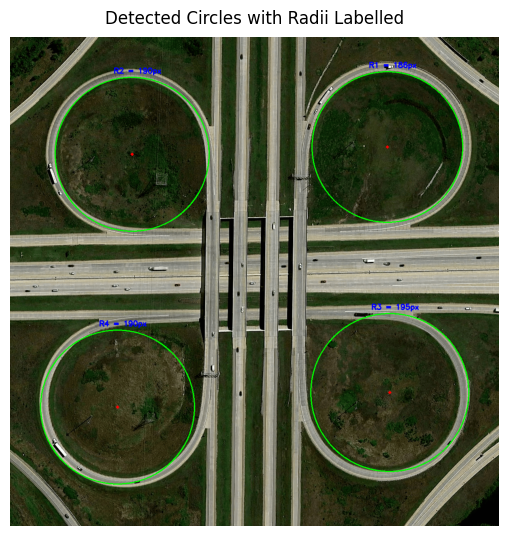

In [15]:
def detect_cloverleaves(preprocessed_image):
    circles = cv2.HoughCircles(
        preprocessed_image,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=180,
        param1=80,
        param2=80,
        minRadius=150,
        maxRadius=200,
    )
    return circles


def measure_radii(original_image, preprocessed_image):
    circles  = detect_cloverleaves(preprocessed_image)
    annotated = original_image.copy()
    radii    = []

    if circles is not None:
        circles_int = np.uint16(np.around(circles))
        for idx, (x, y, r) in enumerate(circles_int[0], start=1):
            x_i, y_i, r_i = int(x), int(y), int(r)
            radii.append(r_i)

            cv2.circle(annotated, (x_i, y_i), r_i, (0, 255, 0), 2)   # boundary
            cv2.circle(annotated, (x_i, y_i), 2, (0, 0, 255), 3)     # centre

            # label positioned just above the top of each circle
            label = f"R{idx} = {r_i}px"
            cv2.putText(annotated, label, (x_i - 45, y_i - r_i - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return radii, annotated


def display_image(img, title=""):
    plt.figure(figsize=(8, 6))
    disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    plt.imshow(disp, cmap=None if img.ndim == 3 else "gray")
    plt.title(title, fontsize=12, pad=10)
    plt.axis("off")
    plt.tight_layout(pad=3.0)
    plt.show()


# measure and display
original_img   = cv2.imread("cloverleaf_interchange.png")
preprocessed_r = preprocess_image(original_img)
radii_list, annotated_img = measure_radii(original_img, preprocessed_r)

print("Detected Cloverleaf Radii (pixels):")
for i, r in enumerate(radii_list, start=1):
    print(f"  Loop {i}: {r} px")
print()

display_image(annotated_img, "Detected Circles with Radii Labelled")
print("\n")


**2.2.3. Approximating the Area Enclosed by Each Cloverleaf**

The `calculate_area()` function approximates the area of each detected cloverleaf using two methods:

    1. Radius-Based Area: Calculates the area as A = π·r² using the radius rr detected by the Hough Circle Transform.
    2. Pixel Counting: Creates a binary mask for each circle and counts the pixels within the circular region.

The Hough Circle Transform (cv2.HoughCircles) detects the circle's center and radius. Detected circles are visualized on the original image with green boundaries, red centers, and labeled areas. Both methods' results are compared, and approximate areas are reported in square pixels. This approach balances efficiency (radius-based) and accuracy (pixel counting).

Cloverleaf 1:
  Method 1 (pi*r^2)     : 108,686.54 sq. pixels
  Method 2 (pixel count): 108,637 sq. pixels
  Difference            : 49.5 sq. pixels

Cloverleaf 2:
  Method 1 (pi*r^2)     : 113,411.49 sq. pixels
  Method 2 (pixel count): 113,369 sq. pixels
  Difference            : 42.5 sq. pixels

Cloverleaf 3:
  Method 1 (pi*r^2)     : 119,459.06 sq. pixels
  Method 2 (pixel count): 119,433 sq. pixels
  Difference            : 26.1 sq. pixels

Cloverleaf 4:
  Method 1 (pi*r^2)     : 113,411.49 sq. pixels
  Method 2 (pixel count): 113,369 sq. pixels
  Difference            : 42.5 sq. pixels





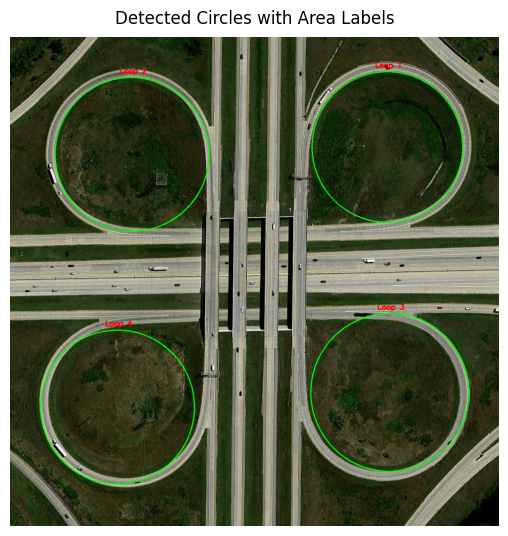

In [16]:
def preprocess_image(image):
    gray    = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blurred, 50, 150)
    kernel  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closed  = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    return closed


def detect_cloverleaves(preprocessed):
    circles = cv2.HoughCircles(
        preprocessed,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=180,
        param1=80,
        param2=80,
        minRadius=150,
        maxRadius=200,
    )
    return circles


def calculate_area(original, preprocessed):
    circles  = detect_cloverleaves(preprocessed)
    annotated = original.copy()

    areas_pi     = []   # method 1: pi * r^2
    areas_pixels = []   # method 2: count filled pixels in binary mask

    if circles is not None:
        circles_int = np.uint16(np.around(circles))
        for i, (x, y, r) in enumerate(circles_int[0], start=1):
            x_i, y_i, r_i = int(x), int(y), int(r)

            # method 1: analytical area using pi*r^2
            area_pi = np.pi * (r_i ** 2)
            areas_pi.append(area_pi)

            # method 2: pixel count inside a filled circular mask
            mask       = np.zeros(preprocessed.shape, dtype=np.uint8)
            cv2.circle(mask, (x_i, y_i), r_i, 255, -1)
            area_px    = int(np.count_nonzero(mask))
            areas_pixels.append(area_px)

            cv2.circle(annotated, (x_i, y_i), r_i, (0, 255, 0), 2)
            cv2.putText(annotated, f"Loop {i}", (x_i - 30, y_i - r_i - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    return areas_pi, areas_pixels, annotated


def display_image(img, title=""):
    plt.figure(figsize=(8, 6))
    disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
    plt.imshow(disp, cmap=None if img.ndim == 3 else "gray")
    plt.title(title, fontsize=12, pad=10)
    plt.axis("off")
    plt.tight_layout(pad=3.0)
    plt.show()


# compute and report areas using both methods
original_a      = cv2.imread("cloverleaf_interchange.png")
preprocessed_a  = preprocess_image(original_a)
area_pi, area_px, annotated_a = calculate_area(original_a, preprocessed_a)

for i, (ap, ax) in enumerate(zip(area_pi, area_px), start=1):
    print(f"Cloverleaf {i}:")
    print(f"  Method 1 (pi*r^2)     : {ap:,.2f} sq. pixels")
    print(f"  Method 2 (pixel count): {ax:,} sq. pixels")
    print(f"  Difference            : {abs(ap - ax):,.1f} sq. pixels")
    print()

print("\n")
display_image(annotated_a, "Detected Circles with Area Labels")
